# Laplacian Eigenmaps for Contig Binning

A classical spectral graph baseline. The smallest non-trivial normalized-Laplacian eigenvectors are concatenated with RepBin-like node features before marker-derived KMeans clustering.

This notebook runs the test dataset 10 times with different seeds, records all metrics for every run, prints min/max/mean/std, and plots mean metric values with standard-deviation error bars. Labels are used only after clustering to evaluate the bins. Node features use the RepBin-like representation: adjacency row + 136 TNF + coverage. The number of clusters is estimated from `contigs.fasta.markers`.

If dependencies are missing in a fresh environment, run:

```python
%pip install agtools torch scikit-learn biopython numpy pandas matplotlib scipy
```

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == 'notebooks':
    REPO_ROOT = NOTEBOOK_DIR.parent
else:
    REPO_ROOT = NOTEBOOK_DIR
sys.path.insert(0, str(REPO_ROOT / 'notebooks'))

from graph_binning_common import *

DATA_DIR = REPO_ROOT / 'tests' / 'data'
SEED = 7
N_RUNS = 10
set_seed(SEED)


In [2]:
data = load_spades_dataset(DATA_DIR)
print_dataset_summary(data)

features = data['features']
adjacency = data['adjacency']
marker_pairs = data['marker_pairs']
labels = data['labels']
label_names = data['label_names']
N_CLUSTERS = data['marker_cluster_count']
print(f'k for clustering from marker genes: {N_CLUSTERS}')
print(f'marker cannot-link pairs: {len(marker_pairs)}')
print(data['feature_names'][:3], '...', data['feature_names'][-3:])


contigs: 509
edges: 1033
features: 646 (509 adjacency + 136 TNF + coverage)
marker sets: 91
marker-derived k: 5
Acetobacter_pasteurianus: 118
Aeromonas_veronii: 72
Amycolatopsis_mediterranei: 105
Arthrobacter_arilaitensis: 195
Azorhizobium_caulinodans: 19
k for clustering from marker genes: 5
marker cannot-link pairs: 1820
['adjacency_to_node_0', 'adjacency_to_node_1', 'adjacency_to_node_2'] ... ['TGCA', 'TTAA', 'log1p_coverage_zscore']


In [3]:
from scipy.linalg import eigh

METHOD_NAME = 'Laplacian Eigenmaps'

def laplacian_eigenmap_embeddings(adjacency, dimensions=32):
    matrix = adjacency.astype(np.float64)
    degree = matrix.sum(axis=1)
    inv_sqrt = np.zeros_like(degree)
    inv_sqrt[degree > 0] = 1.0 / np.sqrt(degree[degree > 0])
    norm_adj = inv_sqrt[:, None] * matrix * inv_sqrt[None, :]
    laplacian = np.eye(matrix.shape[0]) - norm_adj
    values, vectors = eigh(laplacian)
    start = 1 if vectors.shape[1] > 1 else 0
    end = min(start + dimensions, vectors.shape[1])
    emb = vectors[:, start:end]
    if emb.shape[1] < dimensions:
        emb = np.pad(emb, ((0, 0), (0, dimensions - emb.shape[1])))
    return emb.astype(np.float32)

spectral_embeddings = laplacian_eigenmap_embeddings(adjacency, dimensions=32)

def run_once(seed):
    embeddings = np.hstack([spectral_embeddings, features])
    predictions, metrics = run_kmeans(embeddings, labels, seed=seed, n_clusters=N_CLUSTERS)
    return metrics


run 01 seed=7: precision=0.5010, recall=0.5874, f1=0.5408, ari=0.1528, nmi=0.3021
run 02 seed=8: precision=0.5088, recall=0.6012, f1=0.5512, ari=0.1632, nmi=0.3175
run 03 seed=9: precision=0.5029, recall=0.5972, f1=0.5461, ari=0.1597, nmi=0.3089
run 04 seed=10: precision=0.6601, recall=0.7328, f1=0.6946, ari=0.3363, nmi=0.4205
run 05 seed=11: precision=0.5029, recall=0.5815, f1=0.5394, ari=0.1521, nmi=0.2961
run 06 seed=12: precision=0.5029, recall=0.6012, f1=0.5477, ari=0.1626, nmi=0.3130
run 07 seed=13: precision=0.5069, recall=0.6012, f1=0.5500, ari=0.1646, nmi=0.3153
run 08 seed=14: precision=0.5894, recall=0.5599, f1=0.5743, ari=0.2203, nmi=0.3585
run 09 seed=15: precision=0.5049, recall=0.5835, f1=0.5414, ari=0.1517, nmi=0.3015
run 10 seed=16: precision=0.5285, recall=0.5717, f1=0.5492, ari=0.1649, nmi=0.3184


,run,seed,precision,recall,f1,ari,nmi,n_bins_predicted,n_true_bins,aligned_macro_f1
0,1,7,0.500982,0.587426,0.540772,0.152839,0.302089,5,5,0.335820
1,2,8,0.508841,0.601179,0.551169,0.163150,0.317490,5,5,0.332905
2,3,9,0.502947,0.597250,0.546057,0.159671,0.308855,5,5,0.336743
3,4,10,0.660118,0.732809,0.694567,0.336262,0.420462,5,5,0.430813
4,5,11,0.502947,0.581532,0.539392,0.152064,0.296084,5,5,0.336224
5,6,12,0.502947,0.601179,0.547693,0.162622,0.312961,5,5,0.338409
6,7,13,0.506876,0.601179,0.550015,0.164593,0.315345,5,5,0.338884
7,8,14,0.589391,0.559921,0.574278,0.220322,0.358507,5,5,0.446774
8,9,15,0.504912,0.583497,0.541367,0.151710,0.301460,5,5,0.335164
9,10,16,0.528487,0.571709,0.549249,0.164943,0.318393,5,5,0.380426


,min,max,mean,std
precision,0.500982,0.660118,0.530845,0.052813
recall,0.559921,0.732809,0.601768,0.048071
f1,0.539392,0.694567,0.563456,0.047109
ari,0.151710,0.336262,0.182817,0.057490
nmi,0.296084,0.420462,0.325165,0.037638
aligned_macro_f1,0.332905,0.446774,0.361216,0.043334


<Axes: title={'center': 'Laplacian Eigenmaps: mean metrics over 10 runs'}, ylabel='score'>

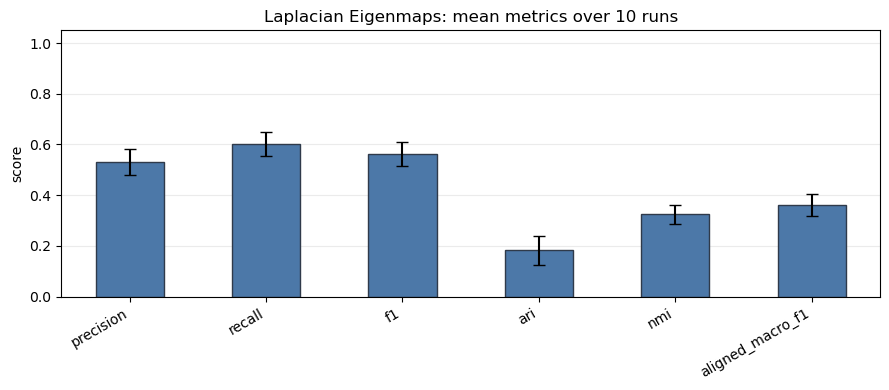

In [4]:
results = run_repeated_experiment(run_once, n_runs=N_RUNS, seed=SEED)
summary = summarize_metric_table(results)

display(results)
display(summary)
plot_metric_bars(summary, title=f'{METHOD_NAME}: mean metrics over {N_RUNS} runs')


## Assembly graph coloured by predicted bin

This plot reruns the method once on the original test graph using `SEED`, captures that method's KMeans bin assignments, and colours contigs in the igraph assembly graph by the predicted bin.

{'precision': 0.5009823182711198, 'recall': 0.587426326129666, 'f1': 0.540771527664494, 'ari': 0.15283917140034084, 'nmi': 0.30208850958864564, 'n_bins_predicted': 5, 'n_true_bins': 5, 'aligned_macro_f1': 0.33581984755203753}
Laplacian Eigenmaps: assembly graph coloured by predicted bin
bin 0: 12 contigs
bin 1: 216 contigs
bin 2: 184 contigs
bin 3: 82 contigs
bin 4: 15 contigs


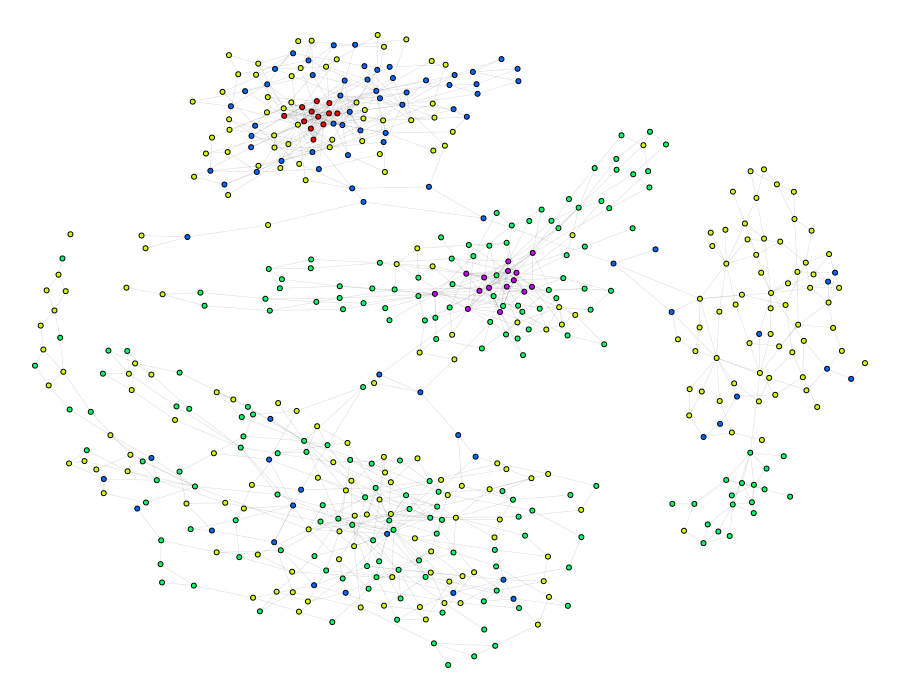

In [5]:
_visual_predictions = None
_original_run_kmeans = run_kmeans

def _capture_run_kmeans(embeddings, labels, seed=7, n_clusters=None):
    global _visual_predictions
    predictions, metrics = _original_run_kmeans(embeddings, labels, seed=seed, n_clusters=n_clusters)
    _visual_predictions = predictions
    return predictions, metrics

run_kmeans = _capture_run_kmeans
try:
    visual_metrics = run_once(SEED)
finally:
    run_kmeans = _original_run_kmeans

print(visual_metrics)
plot_assembly_graph_bins(
    data,
    bins=_visual_predictions,
    title=f'{METHOD_NAME}: assembly graph coloured by predicted bin',
)


## Graph corruption / ablation study

This section reruns the same method under five graph conditions: original assembly graph, random edge removal, random edge addition, coverage-similarity edges added, and short contigs removed. Each condition is run with the same 10 seeds, then metrics are summarized and plotted with standard-deviation error bars.

ablation: original assembly graph
ablation: random edge removal
ablation: random edge addition
ablation: coverage-similarity edges added
ablation: short contigs removed


,ablation,run,seed,precision,recall,f1,ari,nmi,n_bins_predicted,n_true_bins,aligned_macro_f1
0,original assembly graph,1,7,0.500982,0.587426,0.540772,0.152839,0.302089,5,5,0.335820
1,original assembly graph,2,8,0.508841,0.601179,0.551169,0.163150,0.317490,5,5,0.332905
2,original assembly graph,3,9,0.502947,0.597250,0.546057,0.159671,0.308855,5,5,0.336743
3,original assembly graph,4,10,0.660118,0.732809,0.694567,0.336262,0.420462,5,5,0.430813
4,original assembly graph,5,11,0.502947,0.581532,0.539392,0.152064,0.296084,5,5,0.336224
5,original assembly graph,6,12,0.502947,0.601179,0.547693,0.162622,0.312961,5,5,0.338409
6,original assembly graph,7,13,0.506876,0.601179,0.550015,0.164593,0.315345,5,5,0.338884
7,original assembly graph,8,14,0.589391,0.559921,0.574278,0.220322,0.358507,5,5,0.446774
8,original assembly graph,9,15,0.504912,0.583497,0.541367,0.151710,0.301460,5,5,0.335164
9,original assembly graph,10,16,0.528487,0.571709,0.549249,0.164943,0.318393,5,5,0.380426


precision                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.500982  0.660118  0.530845  0.052813   
random edge removal              0.510806  0.654224  0.565226  0.053147   
random edge addition             0.483301  0.658153  0.534381  0.055707   
coverage-similarity edges added  0.646365  0.664047  0.655206  0.005802   
short contigs removed            0.477778  0.620000  0.535333  0.058873   

                                   recall                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.559921  0.732809  0.601768  0.048071   
random edge removal              0.550098  0.709234  0.607466  0.057747   
random edge addition             0.559921  0.730845  0.631434  0.049643   
coverage-similarity edges added  0.693517  0.752456  0.723576  0.016952   
short contigs removed            0.617778  0.717778  0.672222  0.035958   

                                       f1            ...       ari            \
                                      min       max  ...      mean       std   
ablation                                             ...                       
original assembly graph          0.539392  0.694567  ...  0.182817  0.057490   
random edge removal              0.550656  0.680619  ...  0.205554  0.063556   
random edge addition             0.541367  0.692597  ...  0.187802  0.054367   
coverage-similarity edges added  0.674336  0.703269  ...  0.324267  0.006954   
short contigs removed            0.550839  0.665316  ...  0.219119  0.035325   

                                      nmi                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.296084  0.420462  0.325165  0.037638   
random edge removal              0.318847  0.407740  0.347078  0.033533   
random edge addition             0.301322  0.418863  0.331607  0.034953   
coverage-similarity edges added  0.399442  0.415925  0.407377  0.006174   
short contigs removed            0.326433  0.410213  0.357598  0.024165   

                                aligned_macro_f1                                
                                             min       max      mean       std  
ablation                                                                        
original assembly graph                 0.332905  0.446774  0.361216  0.043334  
random edge removal                     0.334851  0.438852  0.391676  0.036333  
random edge addition                    0.308565  0.429541  0.363713  0.045187  
coverage-similarity edges added         0.415223  0.427916  0.421473  0.003454  
short contigs removed                   0.320304  0.438972  0.369457  0.038080  

[5 rows x 24 columns]

<Axes: title={'center': 'Laplacian Eigenmaps: graph corruption / ablation study'}, xlabel='ablation', ylabel='score'>

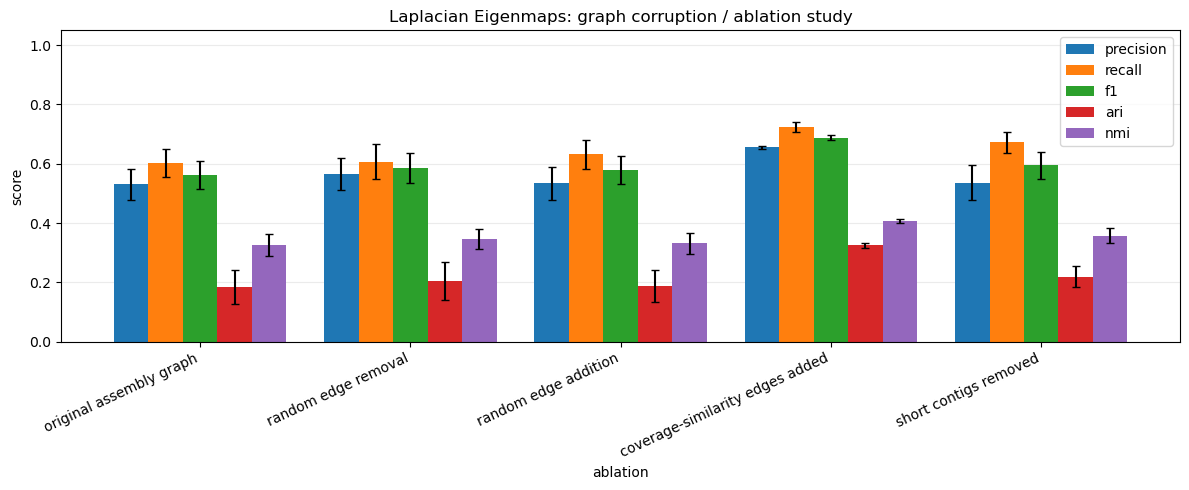

In [6]:
def run_once_ablation(seed, ablation_data):
    global features, adjacency, marker_pairs, labels, label_names, N_CLUSTERS, spectral_embeddings

    old_state = {
        'features': features,
        'adjacency': adjacency,
        'marker_pairs': marker_pairs,
        'labels': labels,
        'label_names': label_names,
        'N_CLUSTERS': N_CLUSTERS,
        'spectral_embeddings': globals().get('spectral_embeddings', None),
    }
    try:
        features = ablation_data['features']
        adjacency = ablation_data['adjacency']
        marker_pairs = ablation_data['marker_pairs']
        labels = ablation_data['labels']
        label_names = ablation_data['label_names']
        N_CLUSTERS = ablation_data['marker_cluster_count']

        # The Laplacian Eigenmaps notebook precomputes graph embeddings outside
        # run_once, so recompute them when the graph changes.
        if 'laplacian_eigenmap_embeddings' in globals():
            spectral_embeddings = laplacian_eigenmap_embeddings(adjacency, dimensions=32)

        return run_once(seed)
    finally:
        features = old_state['features']
        adjacency = old_state['adjacency']
        marker_pairs = old_state['marker_pairs']
        labels = old_state['labels']
        label_names = old_state['label_names']
        N_CLUSTERS = old_state['N_CLUSTERS']
        if old_state['spectral_embeddings'] is not None:
            spectral_embeddings = old_state['spectral_embeddings']

ablation_results, ablation_summary = run_graph_ablation_study(
    data,
    run_once_ablation,
    n_runs=N_RUNS,
    seed=SEED,
)

display(ablation_results)
display(ablation_summary)
plot_ablation_metric_bars(ablation_summary, title=f'{METHOD_NAME}: graph corruption / ablation study')
